Script: Practice with package: Pyicon
- Author: Muxin Hu (muxin.hu@mpimet.mpg.de)
- Date created: 28/10/2025
- Late modified: 04/11/2025 

the package is downloaded and installed in the directory: /home/m/m301254/Download/pyicon


In [2]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dask.array as da
import xarray as xr
import pyicon as pyic
import cartopy.crs as ccrs
import cmocean
%matplotlib inline

import cartopy.feature as cfeature
from matplotlib import cm

from scipy.interpolate import CloughTocher2DInterpolator, LinearNDInterpolator, NearestNDInterpolator

----Start loading pyicon.
Loading default parameters from /home/m/m301254/Download/pyicon/pyicon/params_default.json.
----Start loading pyicon.
----Pyicon was loaded successfully.
----Pyicon was loaded successfully.


# Analysis on ICON-o test run
- for the ICON-o documentation, please go: https://icon-o.gitlab-pages.dkrz.de/icon-o-documentation/
- for the script running the icon-o, please find the section: Quickstart Tutorial + Running ICON-O
    - The current script reference can be visualised in: /work/mh0033/m301254/icon-model/prepare.sh
- The test runs for 10 years, with the results stored in: /work/mh0033/m301254/icon-model/experiments/test20251029/
- The test runs for the ocean model, with the grid resolution as: icon_grid_0036_R02B04_O.nc

In [ ]:
# read output file from ICON-o test run
ds = xr.open_dataset('/work/mh0033/m301254/proj_surfwave/icon_2025_04_2_public/icon-model/experiments/test20251029/test20251029_P1M_3d_20090101T000000Z.nc')
# check the dimensions and variables
ds

<xarray.Dataset> Size: 518MB
Dimensions:                    (ncells: 15105, vertices: 3, ncells_2: 23207,
                                vertices_2: 4, time: 12, depth: 40, depth_2: 41)
Coordinates:
  * time                       (time) datetime64[ns] 96B 2009-01-01 ... 2009-...
  * depth                      (depth) float64 320B 6.0 17.0 ... 5.72e+03
  * depth_2                    (depth_2) float64 328B 0.0 12.0 ... 6.02e+03
    clon                       (ncells) float64 121kB ...
    clat                       (ncells) float64 121kB ...
    elon                       (ncells_2) float64 186kB ...
    elat                       (ncells_2) float64 186kB ...
Dimensions without coordinates: ncells, vertices, ncells_2, vertices_2
Data variables: (12/20)
    clon_bnds                  (ncells, vertices) float64 363kB ...
    clat_bnds                  (ncells, vertices) float64 363kB ...
    elon_bnds                  (ncells_2, vertices_2) float64 743kB ...
    elat_bnds                  (ncells_2, vertices_2) float64 743kB ...
    to                         (time, depth, ncells) float32 29MB ...
    so                         (time, depth, ncells) float32 29MB ...
    ...                         ...
    rhopot                     (time, depth, ncells) float32 29MB ...
    mass_flux                  (time, depth, ncells_2) float32 45MB ...
    heat_content_liquid_water  (time, depth, ncells) float32 29MB ...
    swrab                      (time, depth, ncells) float32 29MB ...
    rsdoabsorb                 (time, depth, ncells) float32 29MB ...
    tke                        (time, depth_2, ncells) float32 30MB ...
Attributes:
    CDI:                  Climate Data Interface version 2.5.2 (https://mpime...
    Conventions:          CF-1.6
    number_of_grid_used:  36
    grid_file_uri:        http://icon-downloads.mpimet.mpg.de/grids/public/mp...
    uuidOfHGrid:          5bd948e8-ac1a-11ea-a6b1-d317264fdca9
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    title:                ICON simulation
    source:               version: 2025.04-2; revision: icon-2025.04-2-public...
    history:              /work/mh0033/m301254/icon-model/bin/icon at 2025102...
    references:           see MPIM/DWD publications
    comment:              Muxin Hu (m301254) on l30472 (Linux 4.18.0-553.74.1...

## Quick check to with the pyicon.plot

(<GeoAxes: title={'right': '2009-12-01T00:00:00'}>,
  <matplotlib.colorbar.Colorbar at 0x7ff2cf336150>])

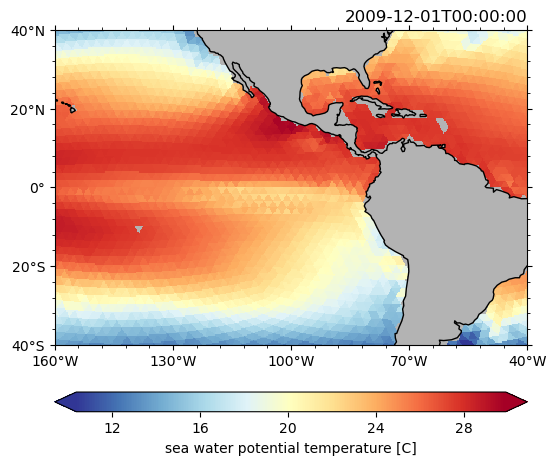

In [4]:
# Quick look at the to data
ds.to.isel(time=-1, depth=0).pyic.plot(
    lon_reg=[-160,-40],
    lat_reg=[-40,40],
    mask_data=True,
    # projection=ccrs.Miller(),
)

## Scattor plot with ICON cells

In [5]:
# read the grid file
ds_grid = xr.open_dataset('/home/m/m301254/pyicon_data/grids/r2b4_oce_r0004/icon_grid_0036_R02B04_O.nc')
ds_grid

<xarray.Dataset> Size: 15MB
Dimensions:                         (cell: 15105, nv: 3, edge: 23207, no: 4,
                                     vertex: 8067, ne: 6, nc: 2,
                                     max_stored_decompositions: 4, two_grf: 2,
                                     cell_grf: 14, max_chdom: 1, edge_grf: 24,
                                     vert_grf: 13)
Coordinates:
    clon                            (cell) float64 121kB ...
    clat                            (cell) float64 121kB ...
    elon                            (edge) float64 186kB ...
    elat                            (edge) float64 186kB ...
    vlon                            (vertex) float64 65kB ...
    vlat                            (vertex) float64 65kB ...
Dimensions without coordinates: cell, nv, edge, no, vertex, ne, nc,
                                max_stored_decompositions, two_grf, cell_grf,
                                max_chdom, edge_grf, vert_grf
Data variables: (12/91)
    clon_bnds                       (cell, nv) float64 363kB ...
    clat_bnds                       (cell, nv) float64 363kB ...
    elon_bnds                       (edge, no) float64 743kB ...
    elat_bnds                       (edge, no) float64 743kB ...
    vlon_bnds                       (vertex, ne) float64 387kB ...
    vlat_bnds                       (vertex, ne) float64 387kB ...
    ...                              ...
    edge_dual_normal_cartesian_x    (edge) float64 186kB ...
    edge_dual_normal_cartesian_y    (edge) float64 186kB ...
    edge_dual_normal_cartesian_z    (edge) float64 186kB ...
    cell_circumcenter_cartesian_x   (cell) float64 121kB ...
    cell_circumcenter_cartesian_y   (cell) float64 121kB ...
    cell_circumcenter_cartesian_z   (cell) float64 121kB ...
Attributes: (12/47)
    CDI:                      Climate Data Interface version 1.9.8 (https://m...
    Conventions:              CF-1.6
    history:                  Wed Jul 15 13:53:13 2020: cdo replace icon_grid...
    number_of_grid_used:      36
    grid_file_uri:            http://icon-downloads.mpimet.mpg.de/grids/publi...
    uuidOfHGrid:              5bd948e8-ac1a-11ea-a6b1-d317264fdca9
    ...                       ...
    topography:               modified SRTM30 as in0014 but with improved top...
    symmetry:                 along equator
    subcentre:                0
    ICON_grid_file_uri:       http://icon-downloads.mpimet.mpg.de/grids/publi...
    NCO:                      netCDF Operators version 4.7.5 (Homepage = http...
    CDO:                      Climate Data Operators version 1.9.8 (https://m...

In [6]:
# icon data assignment
gridICON = ds_grid
dataICON = ds

# icon celss
lon_icon = gridICON.clon.values*180/np.pi
lat_icon = gridICON.clat.values*180/np.pi

# choose one layer and time data
ds_sample_icon = dataICON.to.isel(time=-1, depth=0).values

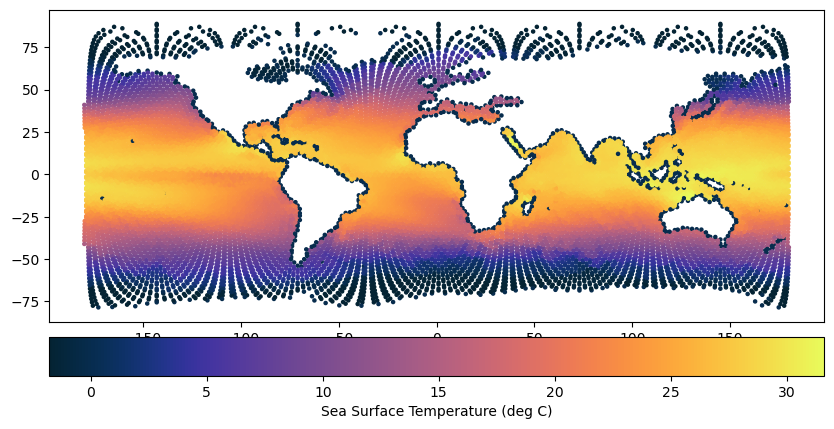

In [7]:
# scattor plot
plt.figure(figsize=(10,5))
plt.scatter(lon_icon, lat_icon, c=ds_sample_icon, s=5, cmap=cmocean.cm.thermal)
plt.colorbar(label='Sea Surface Temperature (deg C)', orientation='horizontal', pad=0.04)
plt.show()

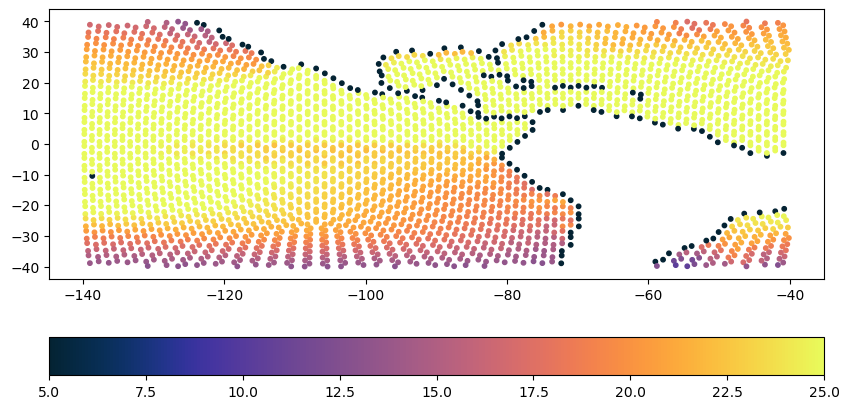

In [8]:
# define the region by the lon and lat limits
left = -140
right = -40
bottom = -40
top = 40

# focus on a region
regionICON = (lon_icon >= left) & (lon_icon <= right) & (lat_icon >= bottom) & (lat_icon <= top)

sstep = 1 # step for scatter plot
plt.figure(figsize=(10,5))
plt.scatter(lon_icon[regionICON][::sstep], 
            lat_icon[regionICON][::sstep], 
            s=10 , c=ds_sample_icon[regionICON][::sstep], cmap=cmocean.cm.thermal, vmin=5, vmax=25)
plt.colorbar(orientation='horizontal')

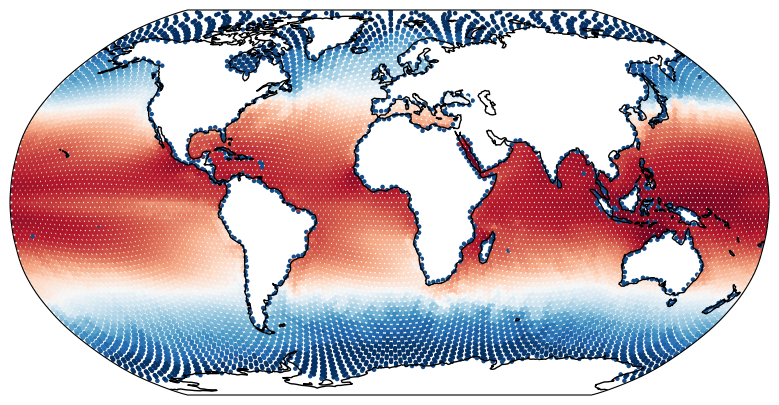

In [9]:
# icon with coatlines
sstep = 1    # step for scatter plot, 1 means all points
plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.Robinson())
ax.coastlines(resolution='110m', color='k')
ax.scatter(lon_icon[::sstep], lat_icon[::sstep], s=5 , c=ds_sample_icon[::sstep],
            cmap=cm.RdBu_r, transform=ccrs.PlateCarree())

## Simple interpolation to regular grid

### Lat, Lon pairs; prefix of interpolation

In [10]:
%%time
# creates a 2D arrya of lon and lat paris for icon grid points
points_icon = np.vstack((lon_icon, lat_icon)).T    # stacks arrays in sequence vertically (row wise)

# fastest way
nn_interpolation_icon = NearestNDInterpolator(points_icon, ds_sample_icon)   # knows where the original grid poinst are; what values they have
# linear
# nn_interpolation_icon = LinearNDInterpolator(points_icon, ds_sample_icon)
# bilinear
# nn_interpolation_icon = CloughTocher2DInterpolator(points_icon, ds_sample_icon)

CPU times: user 4.34 ms, sys: 15 μs, total: 4.35 ms
Wall time: 4.18 ms


### Regular grid

In [11]:
# create a regular grid to interpolate the data onto
# alternative input could be grid from observation
# lon = np.linspace(-180, 180, 360)
# lat = np.linspace(-90, 90, 180)

lon = np.linspace(left, right, 120)    # creates 60 evenly spaced points 
lat = np.linspace(bottom, top, 120)      

lon2, lat2 = np.meshgrid(lon, lat)

In [12]:
# perform the interpolation on the regular grid
interpolated_nn_icon = nn_interpolation_icon((lon2, lat2))
icon_interpolated_global = interpolated_nn_icon
# if lon2 and lat2 are limited regions, the interpolated_nn_icon will be for that region only

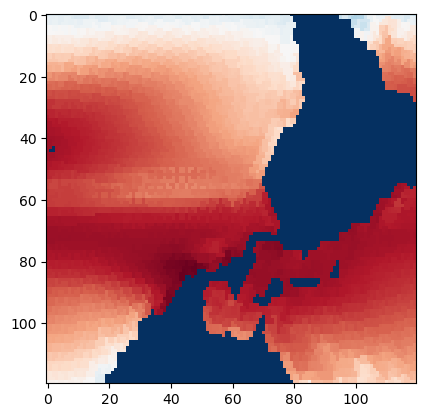

In [13]:
plt.imshow(icon_interpolated_global, cmap=cm.RdBu_r)

### Contourf and Contour

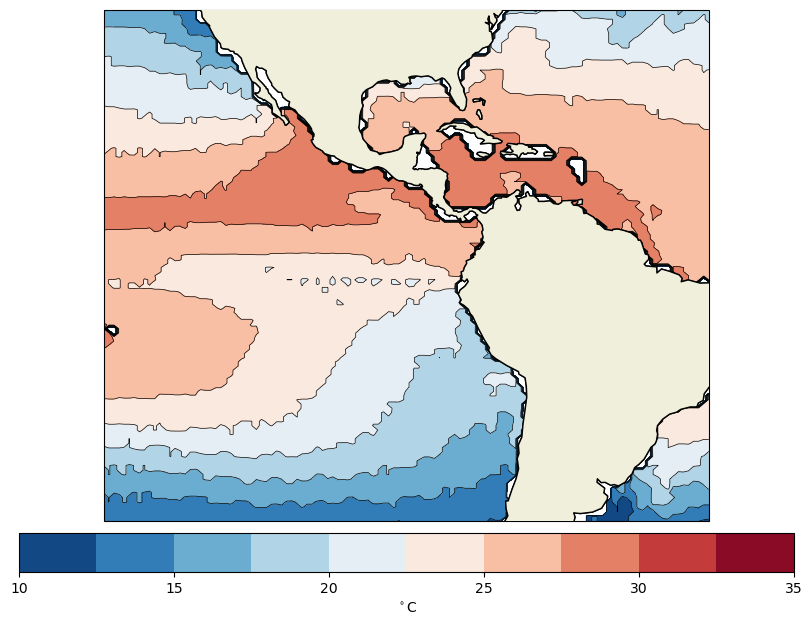

In [14]:
# plot the interpolated data on map
sstep = 1
plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.Miller())
ax.coastlines(resolution='110m', color='k')
# ax.set_extent([left, right, bottom, top], crs=ccrs.PlateCarree())
img = ax.contourf(lon2, lat2, icon_interpolated_global, 
           levels = np.linspace(10,35, 11),
           #levels = np.linspace(-2,30,27),
           cmap=cm.RdBu_r, transform=ccrs.PlateCarree())
ax.contour(lon2, lat2, icon_interpolated_global, 
           levels = np.linspace(10,35,11),
           #levels = np.linspace(-2,30,27),
           transform=ccrs.PlateCarree(), zorder=10, colors='k', linewidths=0.5)
ax.add_feature(cfeature.LAND, zorder=10, edgecolor='black')
#ax.stock_img()
cbar = plt.colorbar(img, orientation='horizontal', pad=0.02)
cbar.set_label('$^\circ$C')